#  Module 1 — Hands-On: Building a Neural Network from Scratch
## Recognising Handwritten Digits with the MNIST Dataset

> **Objective:** In the theory session we learnt *what* a neural network does.  
> Now we will **build one step-by-step** and watch it learn to recognise handwritten digits.

### What We Will Cover
1. **Loading & Exploring** the MNIST dataset  
2. **Visualising** the data (pixels → numbers)  
3. **Building** a Multi-Layer Perceptron (MLP) with PyTorch  
4. **Training** the network (forward pass → loss → back-propagation → gradient descent)  
5. **Evaluating** performance on unseen test images  
6. **Experimenting** — change layers, neurons, activation functions, and see what happens!

---
## 1. Setup — Install & Import Libraries

We will use **PyTorch** — the most popular deep-learning framework used in research and industry.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

# Nice inline plots
# matplotlib inline
plt.rcParams['figure.dpi'] = 120

# Check if a GPU is available (optional - works fine on CPU too)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


---
## 2. Loading the MNIST Dataset

MNIST contains **60,000 training** and **10,000 test** images of handwritten digits (0–9).  
Each image is a **28 × 28** grayscale image — exactly what we discussed in the theory module!

In [2]:
# Download & prepare MNIST
# transforms.ToTensor() converts each image into a PyTorch tensor
# and automatically scales pixel values from [0, 255] to [0.0, 1.0]
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f'Training samples : {len(train_dataset)}')
print(f'Test samples     : {len(test_dataset)}')
print(f'Image shape      : {train_dataset[0][0].shape}  ->  1 channel x 28 x 28 pixels')

100%|██████████| 9.91M/9.91M [00:00<00:00, 52.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.76MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.92MB/s]

Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])  ->  1 channel x 28 x 28 pixels


---
## 3. Visualising the Data

Let's look at a few sample images and their labels — just like the images we saw in the theory session.

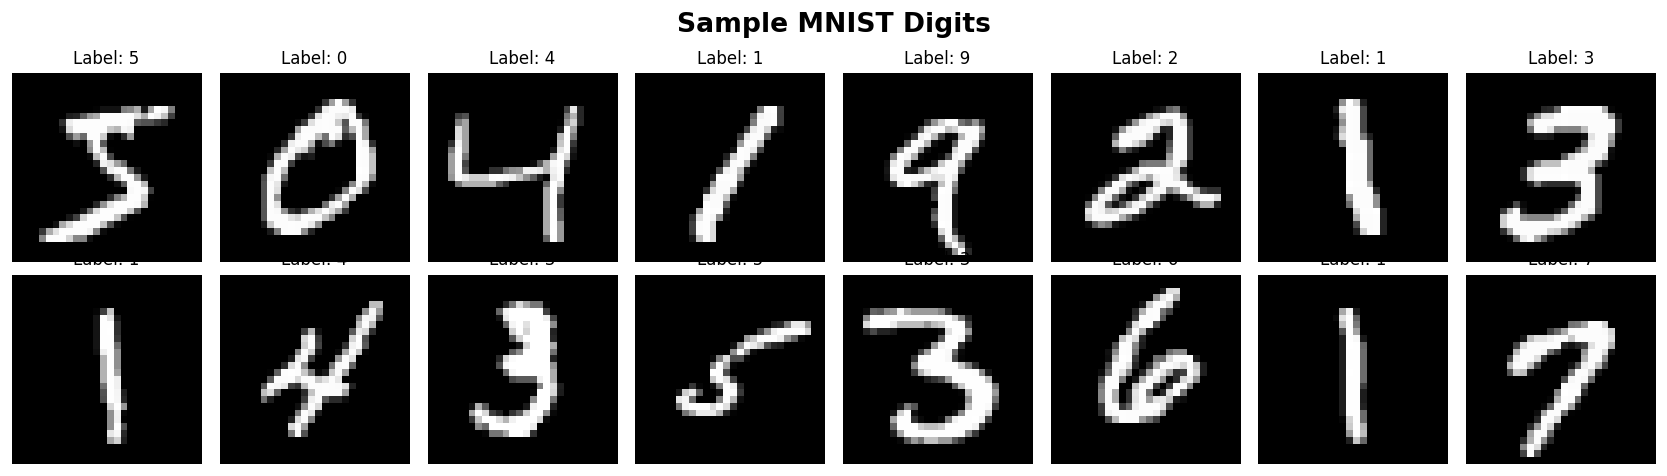

In [3]:
# Show a grid of sample digits
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Sample MNIST Digits', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

###  Let's zoom into a single digit and look at the raw pixel values
Remember from the theory: each pixel holds a number between **0** (black) and **1** (white) — the **activation** value.

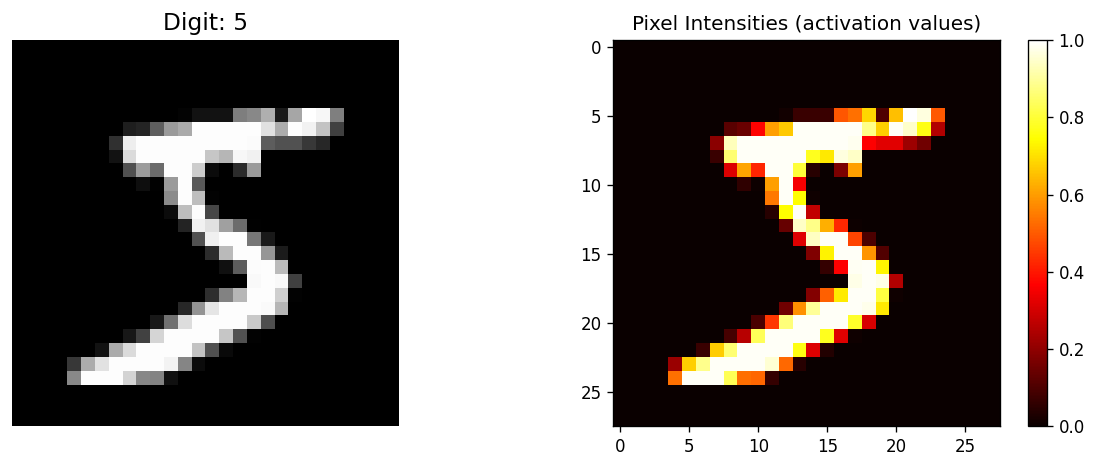

Image shape : (28, 28)
Min pixel   : 0.0000
Max pixel   : 1.0000
Total pixels: 784 (= 28 x 28 = 784 -- our input layer!)


In [4]:
# Raw pixel values of a single image
image, label = train_dataset[0]
pixel_grid = image.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left - the image
axes[0].imshow(pixel_grid, cmap='gray')
axes[0].set_title(f'Digit: {label}', fontsize=14)
axes[0].axis('off')

# Right - a heatmap of pixel intensities
im = axes[1].imshow(pixel_grid, cmap='hot', interpolation='nearest')
axes[1].set_title('Pixel Intensities (activation values)', fontsize=12)
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

print(f'Image shape : {pixel_grid.shape}')
print(f'Min pixel   : {pixel_grid.min():.4f}')
print(f'Max pixel   : {pixel_grid.max():.4f}')
print(f'Total pixels: {pixel_grid.size} (= 28 x 28 = 784 -- our input layer!)')

---
## 4. From Image to Input Layer — Flattening

In our theory we saw that the **input layer** has **784 neurons**, one per pixel.  
To feed the 28×28 image into the network, we **flatten** it into a single row of 784 numbers.

Original shape : (28, 28)
Flattened shape: (784,)
First 20 values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


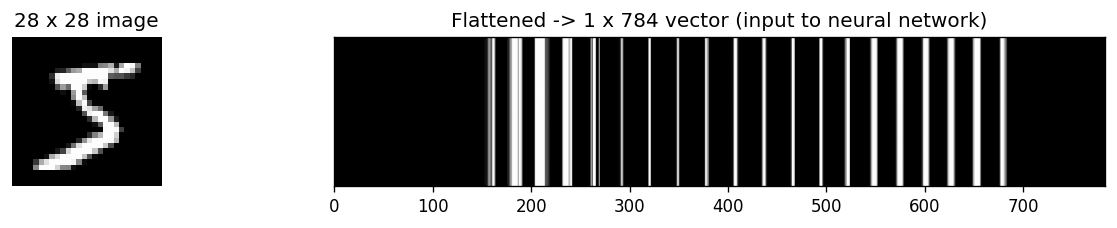

In [5]:
# Flatten a 28x28 image into a 784-element vector
flat = pixel_grid.flatten()
print(f'Original shape : {pixel_grid.shape}')
print(f'Flattened shape: {flat.shape}')
print(f'First 20 values: {flat[:20].round(3)}')

# Visualise the flattening
fig, axes = plt.subplots(1, 2, figsize=(12, 2))
axes[0].imshow(pixel_grid, cmap='gray')
axes[0].set_title('28 x 28 image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(flat.reshape(1, -1), cmap='gray', aspect='auto')
axes[1].set_title('Flattened -> 1 x 784 vector (input to neural network)', fontsize=12)
axes[1].set_yticks([])
plt.tight_layout()
plt.show()

---
## 5. Building the Neural Network (Multi-Layer Perceptron)

Now we build the **exact architecture** we discussed in class:

| Layer | Neurons | Description |
|---|---|---|
| Input  | **784** | One neuron per pixel (28 × 28) |
| Hidden 1 | **16** | First hidden layer |
| Hidden 2 | **16** | Second hidden layer |
| Output | **10** | One neuron per digit (0–9) |

We will use **ReLU** as the activation function (recall: modern networks prefer ReLU over sigmoid).

###  Parameter Count
From the theory:
- Input → Hidden 1: 784 × 16 weights + 16 biases = **12,560**
- Hidden 1 → Hidden 2: 16 × 16 weights + 16 biases = **272**
- Hidden 2 → Output: 16 × 10 weights + 10 biases = **170**
- **Total: 13,002 parameters** — exactly what we calculated!

In [6]:
# Define the MLP
class MLP(nn.Module):
    '''Multi-Layer Perceptron for MNIST digit classification.
    Architecture: 784 -> 16 (ReLU) -> 16 (ReLU) -> 10
    '''
    def __init__(self):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),                       # 28x28 -> 784
            nn.Linear(784, 16),                 # Input -> Hidden 1
            nn.ReLU(),                          # Activation function
            nn.Linear(16, 16),                  # Hidden 1 -> Hidden 2
            nn.ReLU(),                          # Activation function
            nn.Linear(16, 10),                  # Hidden 2 -> Output
        )

    def forward(self, x):
        return self.network(x)

# Create the model and move it to the device (CPU or GPU)
model = MLP().to(device)
print(model)

MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=16, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=10, bias=True)
  )
)


In [7]:
# Count the parameters
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')
print()

# Breakdown by layer
for name, param in model.named_parameters():
    print(f'  {name:30s}  shape={str(list(param.shape)):15s}  params={param.numel():,}')


Total trainable parameters: 13,002

  network.1.weight                shape=[16, 784]        params=12,544
  network.1.bias                  shape=[16]             params=16
  network.3.weight                shape=[16, 16]         params=256
  network.3.bias                  shape=[16]             params=16
  network.5.weight                shape=[10, 16]         params=160
  network.5.bias                  shape=[10]             params=10


 **13,002 parameters** — exactly matching our theory!

Each of these 13,002 numbers will be *learned* during training. Right now they are random — the network knows nothing yet.

---
## 6. Visualising the Initial (Random) Weights

Before training, the weights are **random**. Let's visualise what the 16 neurons in the first hidden layer are "looking for" — each neuron has 784 weights, which we can reshape back into a 28×28 grid.

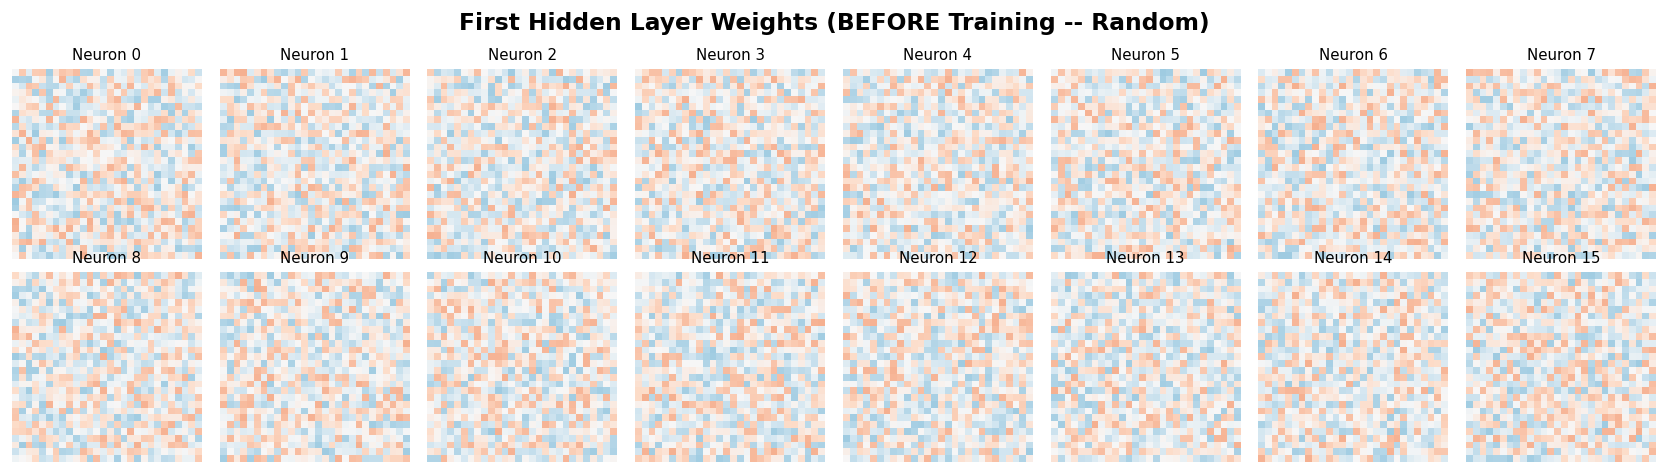

These are random -- the network has not learned anything yet!


In [8]:
# Visualise weights of first hidden layer
first_layer_weights = model.network[1].weight.data.cpu().numpy()  # shape: (16, 784)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('First Hidden Layer Weights (BEFORE Training -- Random)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    w = first_layer_weights[i].reshape(28, 28)
    ax.imshow(w, cmap='RdBu', vmin=-0.1, vmax=0.1)
    ax.set_title(f'Neuron {i}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print('These are random -- the network has not learned anything yet!')

---
## 7. Training the Network — Gradient Descent in Action!

### What happens during training:
1. **Forward Pass** — feed an image through the network, get a prediction  
2. **Compute Loss** — how wrong is the prediction? (Cross-Entropy Loss)  
3. **Backward Pass** — compute gradients (how to adjust each weight)  
4. **Update Weights** — use **gradient descent** to nudge weights in the right direction  
5. Repeat for all images, for multiple **epochs** (complete passes through the dataset)

In [9]:
# Training hyperparameters
BATCH_SIZE    = 64       # Number of images per mini-batch
LEARNING_RATE = 0.01     # Step size for gradient descent
EPOCHS        = 10       # Number of complete passes through the training data

# DataLoaders handle batching and shuffling for us
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Loss function - Cross-Entropy (standard for classification)
criterion = nn.CrossEntropyLoss()

# Optimiser - Stochastic Gradient Descent (SGD)
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)

print(f'Batch size     : {BATCH_SIZE}')
print(f'Learning rate  : {LEARNING_RATE}')
print(f'Epochs         : {EPOCHS}')
print(f'Batches/epoch  : {len(train_loader)}')

Batch size     : 64
Learning rate  : 0.01
Epochs         : 10
Batches/epoch  : 938


 Let's Train!

In [10]:
# Training loop
train_losses = []
test_accuracies = []

for epoch in range(1, EPOCHS + 1):
    # TRAIN
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # 1. Forward pass
        outputs = model(images)

        # 2. Compute loss
        loss = criterion(outputs, labels)

        # 3. Backward pass (compute gradients)
        optimizer.zero_grad()
        loss.backward()

        # 4. Update weights (gradient descent step)
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # EVALUATE on test set
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total
    test_accuracies.append(accuracy)

    print(f'Epoch {epoch:2d}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  Test Accuracy: {accuracy:.2f}%')

print('\nTraining complete!')

Epoch  1/10  |  Loss: 1.8589  |  Test Accuracy: 72.95%
Epoch  2/10  |  Loss: 0.7333  |  Test Accuracy: 84.60%
Epoch  3/10  |  Loss: 0.4952  |  Test Accuracy: 88.09%
Epoch  4/10  |  Loss: 0.4088  |  Test Accuracy: 89.52%
Epoch  5/10  |  Loss: 0.3677  |  Test Accuracy: 90.14%
Epoch  6/10  |  Loss: 0.3424  |  Test Accuracy: 90.57%
Epoch  7/10  |  Loss: 0.3236  |  Test Accuracy: 91.06%
Epoch  8/10  |  Loss: 0.3082  |  Test Accuracy: 91.42%
Epoch  9/10  |  Loss: 0.2954  |  Test Accuracy: 91.66%
Epoch 10/10  |  Loss: 0.2840  |  Test Accuracy: 92.05%

Training complete!


---
## 8. Training Results — Did the Network Learn?

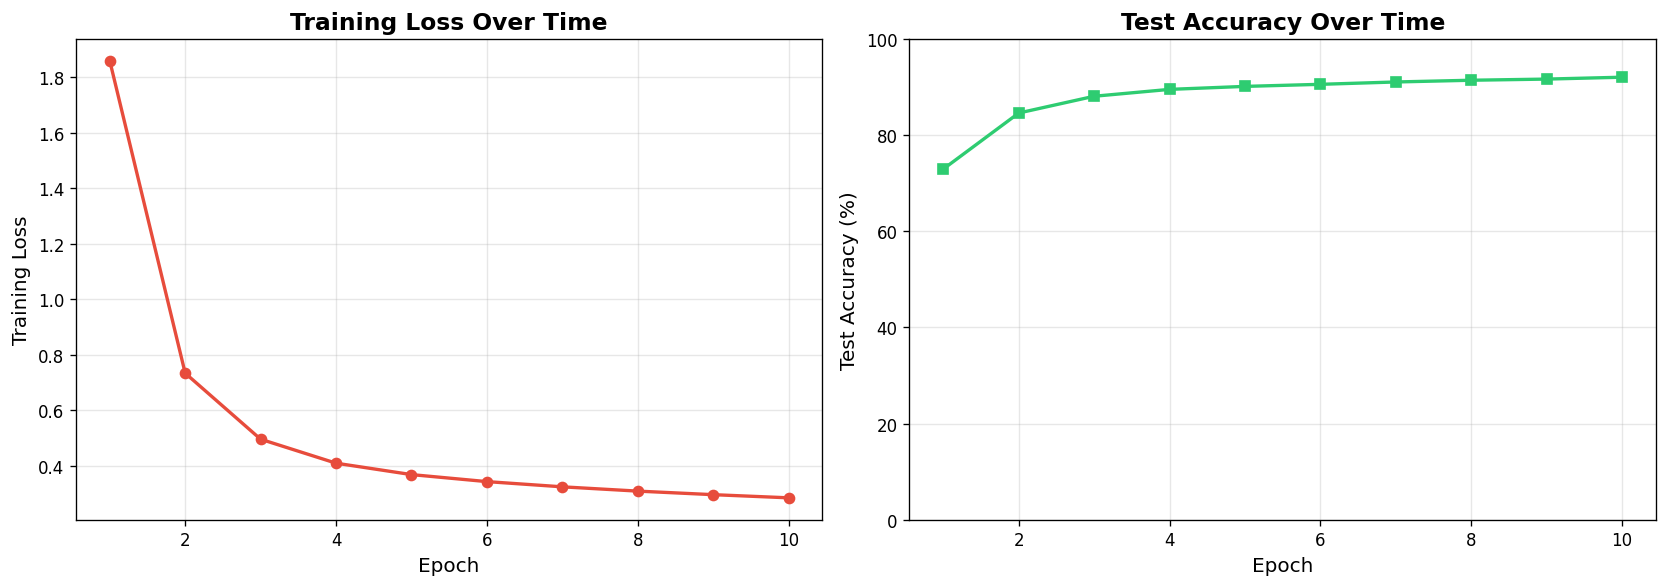

Final test accuracy: 92.05%


In [11]:
# Plot training loss and test accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(range(1, EPOCHS + 1), train_losses, 'o-', color='#e74c3c', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(range(1, EPOCHS + 1), test_accuracies, 's-', color='#2ecc71', linewidth=2, markersize=6)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Test Accuracy Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f'Final test accuracy: {test_accuracies[-1]:.2f}%')

---
## 9. What Did the Network Learn?

Let's look at the first hidden layer's weights **after training** and compare them with the random weights from before.

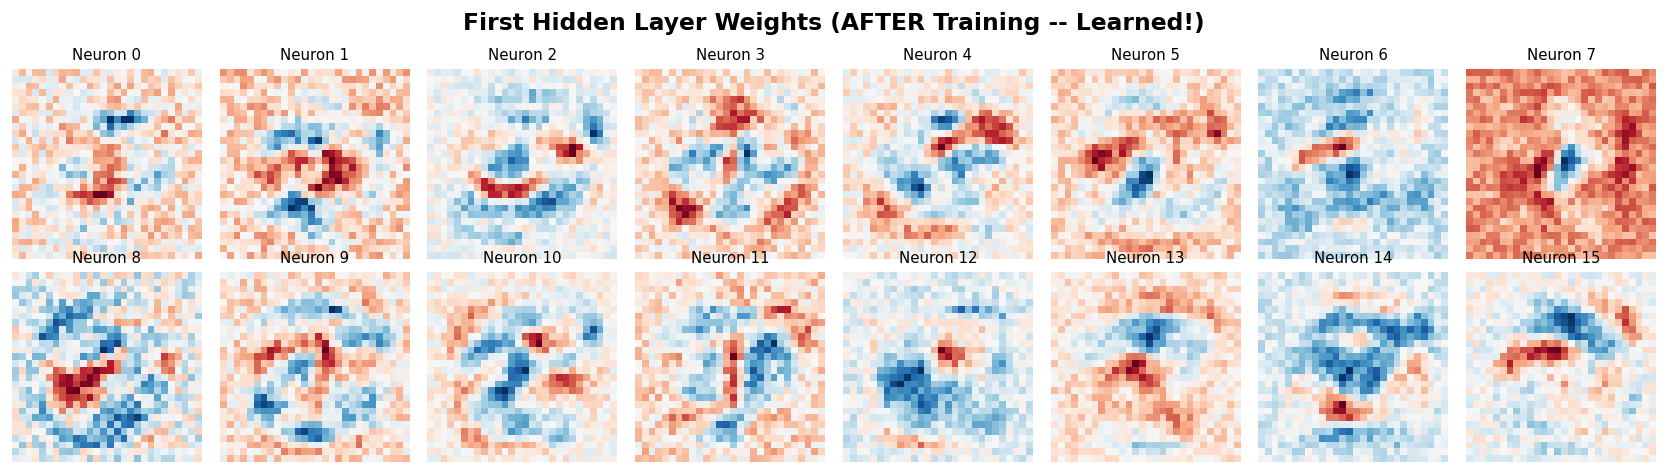

Each neuron has learned to detect specific patterns/edges in the input image!
Red = negative weights (suppress)  |  Blue = positive weights (activate)


In [12]:
# Visualise weights AFTER training
first_layer_weights = model.network[1].weight.data.cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('First Hidden Layer Weights (AFTER Training -- Learned!)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    w = first_layer_weights[i].reshape(28, 28)
    ax.imshow(w, cmap='RdBu', vmin=w.min(), vmax=w.max())
    ax.set_title(f'Neuron {i}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print('Each neuron has learned to detect specific patterns/edges in the input image!')
print('Red = negative weights (suppress)  |  Blue = positive weights (activate)')

---
## 10. Testing on Individual Images

Let's pick some test images and see what the network predicts, along with its **confidence** (the output activations for each digit).

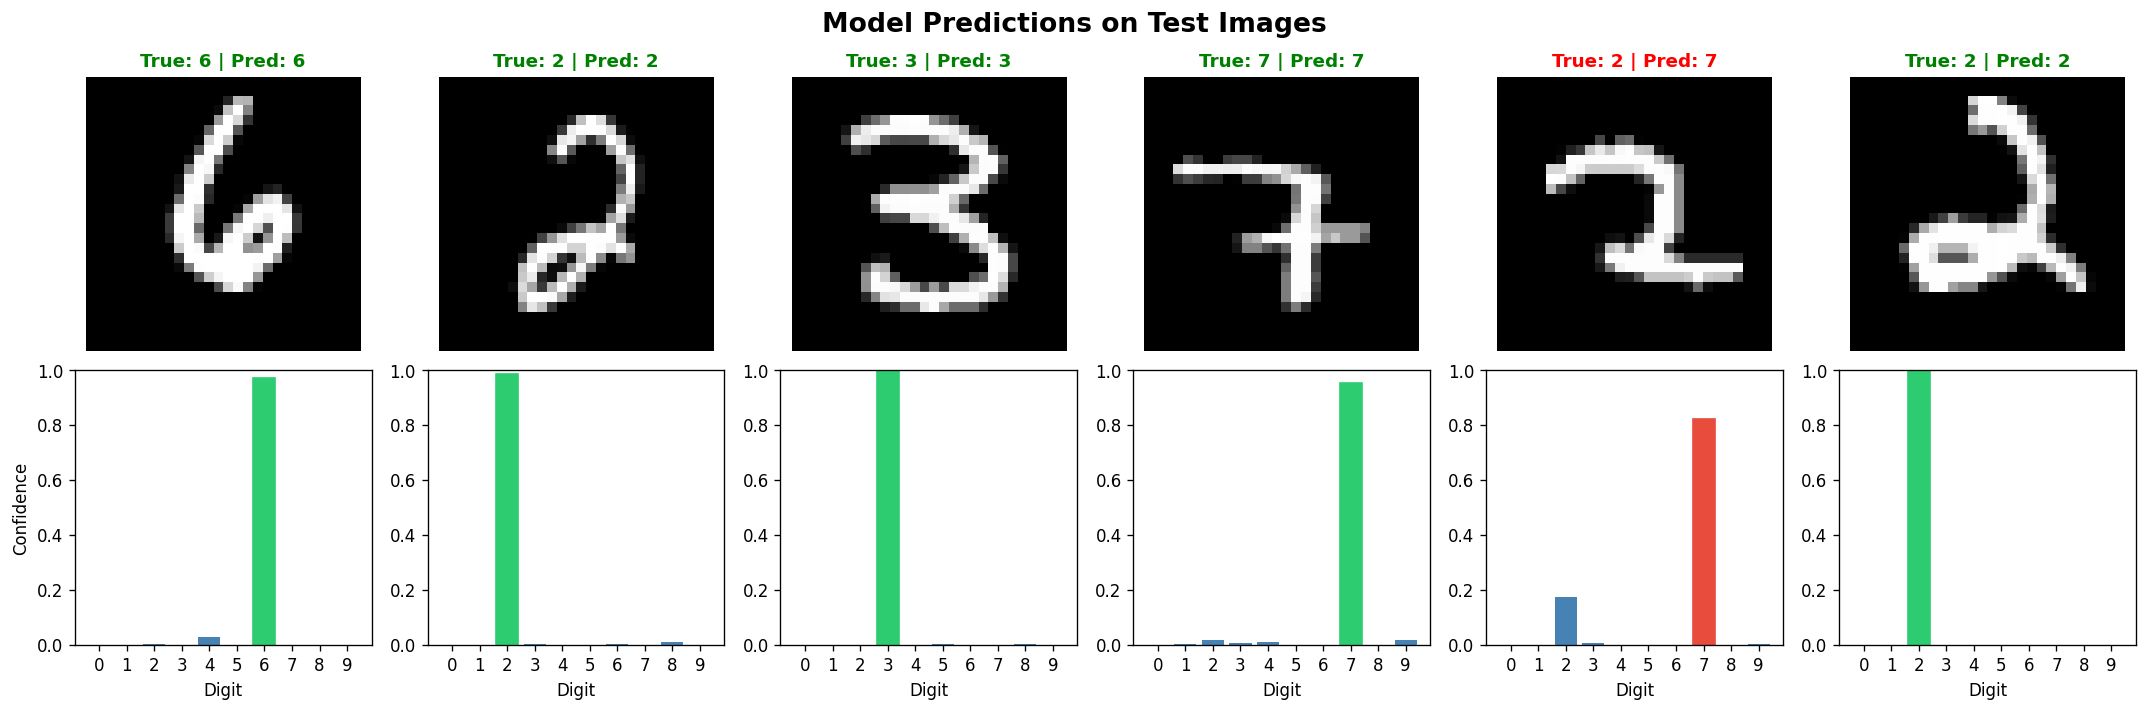

In [13]:
# Predict on individual test images
def predict_and_show(model, dataset, indices):
    '''Show predictions for specific test images.'''
    fig, axes = plt.subplots(2, len(indices), figsize=(3 * len(indices), 6))

    model.eval()
    with torch.no_grad():
        for col, idx in enumerate(indices):
            image, true_label = dataset[idx]
            output = model(image.unsqueeze(0).to(device))
            probabilities = torch.softmax(output, dim=1).cpu().squeeze().numpy()
            predicted_label = probabilities.argmax()

            # Top row - the image
            axes[0, col].imshow(image.squeeze(), cmap='gray')
            color = 'green' if predicted_label == true_label else 'red'
            axes[0, col].set_title(
                f'True: {true_label} | Pred: {predicted_label}',
                fontsize=11, fontweight='bold', color=color
            )
            axes[0, col].axis('off')

            # Bottom row - confidence bar chart
            bars = axes[1, col].bar(range(10), probabilities, color='steelblue')
            bars[predicted_label].set_color('#2ecc71' if predicted_label == true_label else '#e74c3c')
            axes[1, col].set_xticks(range(10))
            axes[1, col].set_ylim(0, 1)
            axes[1, col].set_xlabel('Digit')
            if col == 0:
                axes[1, col].set_ylabel('Confidence')

    plt.suptitle('Model Predictions on Test Images', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show predictions for 6 random test images
np.random.seed(42)
random_indices = np.random.choice(len(test_dataset), size=6, replace=False)
predict_and_show(model, test_dataset, random_indices)

---
## 11. Confusion Matrix — Where Does the Network Make Mistakes?

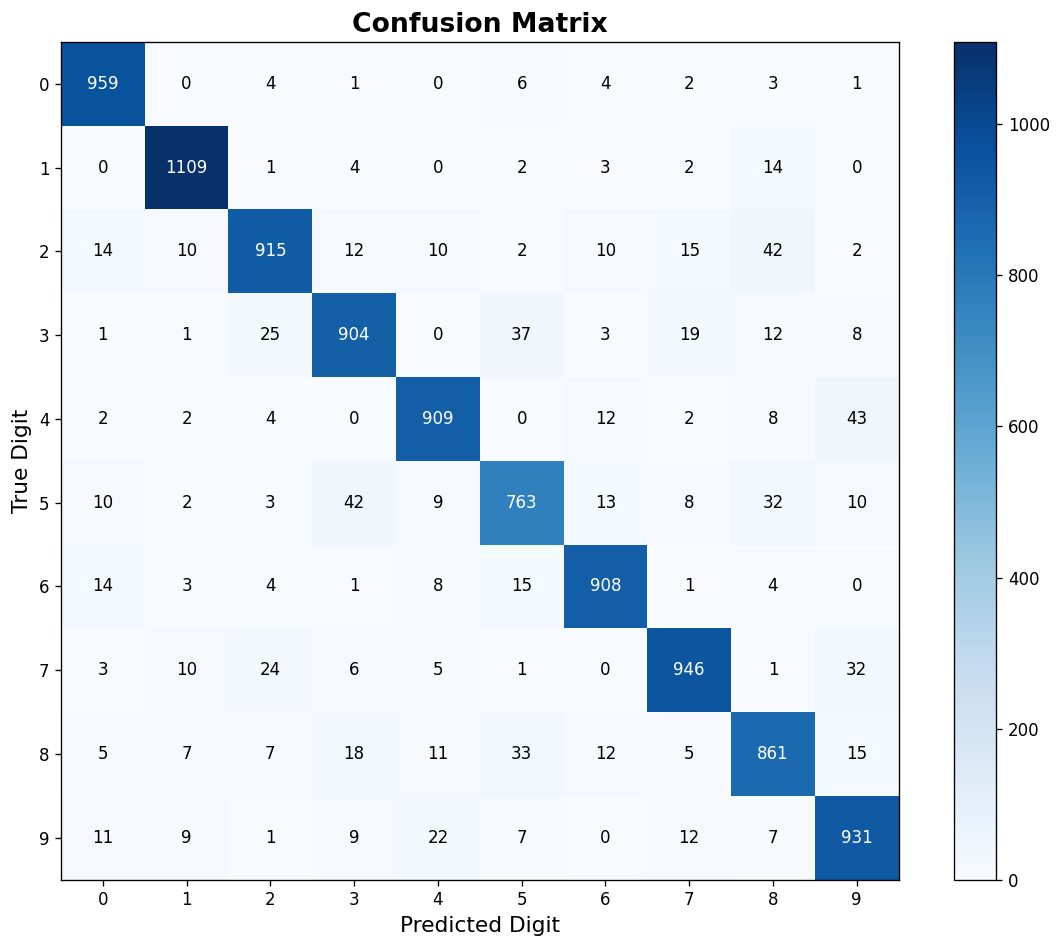

              precision    recall  f1-score   support

           0      0.941     0.979     0.959       980
           1      0.962     0.977     0.969      1135
           2      0.926     0.887     0.906      1032
           3      0.907     0.895     0.901      1010
           4      0.933     0.926     0.929       982
           5      0.881     0.855     0.868       892
           6      0.941     0.948     0.944       958
           7      0.935     0.920     0.927      1028
           8      0.875     0.884     0.879       974
           9      0.893     0.923     0.908      1009

    accuracy                          0.920     10000
   macro avg      0.919     0.919     0.919     10000
weighted avg      0.920     0.920     0.920     10000



In [14]:
# Compute predictions on the entire test set
from sklearn.metrics import confusion_matrix, classification_report

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')

# Add text annotations
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=10)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Predicted Digit', fontsize=13)
ax.set_ylabel('True Digit', fontsize=13)
ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, digits=3))

 Let's look at some images the network got **wrong**

Total misclassified: 795 out of 10000 (7.95%)



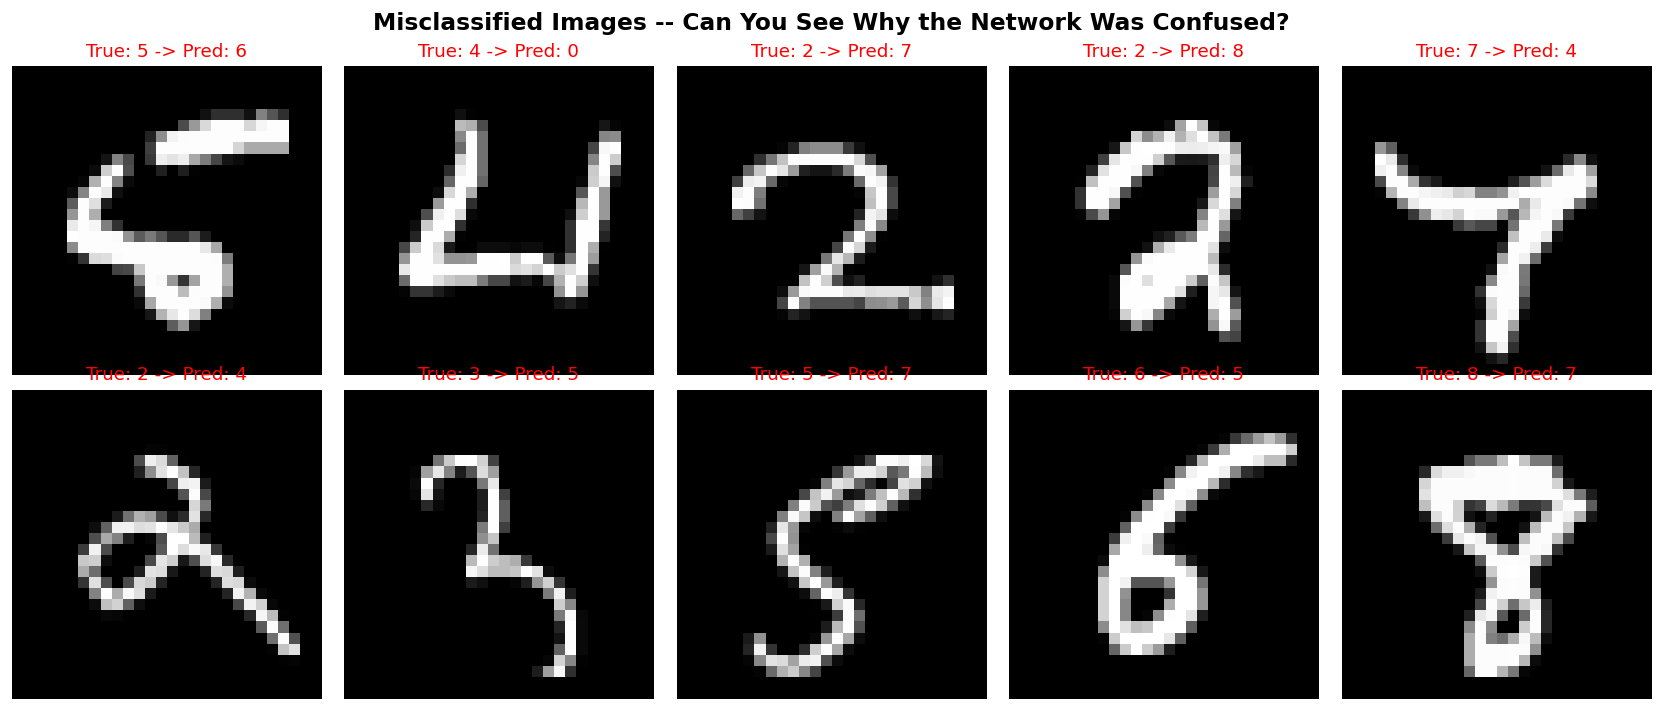

In [15]:
# Find and display misclassified images
all_preds_arr = np.array(all_preds)
all_labels_arr = np.array(all_labels)
misclassified = np.where(all_preds_arr != all_labels_arr)[0]

print(f'Total misclassified: {len(misclassified)} out of {len(all_labels_arr)} '
      f'({100 * len(misclassified) / len(all_labels_arr):.2f}%)')
print()

# Show first 10 misclassified
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Misclassified Images -- Can You See Why the Network Was Confused?',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(misclassified):
        idx = misclassified[i]
        image, true_label = test_dataset[idx]
        ax.imshow(image.squeeze(), cmap='gray')
        ax.set_title(f'True: {true_label} -> Pred: {all_preds_arr[idx]}', fontsize=11, color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

---
## 12.  Experiment: Sigmoid vs. ReLU

In the theory session we learnt that modern networks prefer **ReLU** over **Sigmoid**.  
Let's prove it! We will train the same network with sigmoid and compare.

In [16]:
# Build a Sigmoid model for comparison
class MLP_Sigmoid(nn.Module):
    '''Same architecture but with Sigmoid activation instead of ReLU.'''
    def __init__(self):
        super(MLP_Sigmoid, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 16),
            nn.Sigmoid(),                       # <-- Sigmoid instead of ReLU
            nn.Linear(16, 16),
            nn.Sigmoid(),                       # <-- Sigmoid instead of ReLU
            nn.Linear(16, 10),
        )

    def forward(self, x):
        return self.network(x)

# Train the Sigmoid model
model_sigmoid = MLP_Sigmoid().to(device)
optimizer_sigmoid = optim.SGD(model_sigmoid.parameters(), lr=LEARNING_RATE)

sigmoid_losses = []
sigmoid_accuracies = []

print('Training Sigmoid model...')
for epoch in range(1, EPOCHS + 1):
    model_sigmoid.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_sigmoid(images)
        loss = criterion(outputs, labels)
        optimizer_sigmoid.zero_grad()
        loss.backward()
        optimizer_sigmoid.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    sigmoid_losses.append(avg_loss)

    model_sigmoid.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_sigmoid(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total
    sigmoid_accuracies.append(accuracy)
    print(f'  Epoch {epoch:2d}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  Accuracy: {accuracy:.2f}%')

print('\nSigmoid training complete!')

Training Sigmoid model...
  Epoch  1/10  |  Loss: 2.3062  |  Accuracy: 11.35%
  Epoch  2/10  |  Loss: 2.2955  |  Accuracy: 11.38%
  Epoch  3/10  |  Loss: 2.2896  |  Accuracy: 11.35%
  Epoch  4/10  |  Loss: 2.2807  |  Accuracy: 13.84%
  Epoch  5/10  |  Loss: 2.2657  |  Accuracy: 20.03%
  Epoch  6/10  |  Loss: 2.2386  |  Accuracy: 29.51%
  Epoch  7/10  |  Loss: 2.1896  |  Accuracy: 27.82%
  Epoch  8/10  |  Loss: 2.1118  |  Accuracy: 33.25%
  Epoch  9/10  |  Loss: 2.0103  |  Accuracy: 38.00%
  Epoch 10/10  |  Loss: 1.8917  |  Accuracy: 42.85%

Sigmoid training complete!


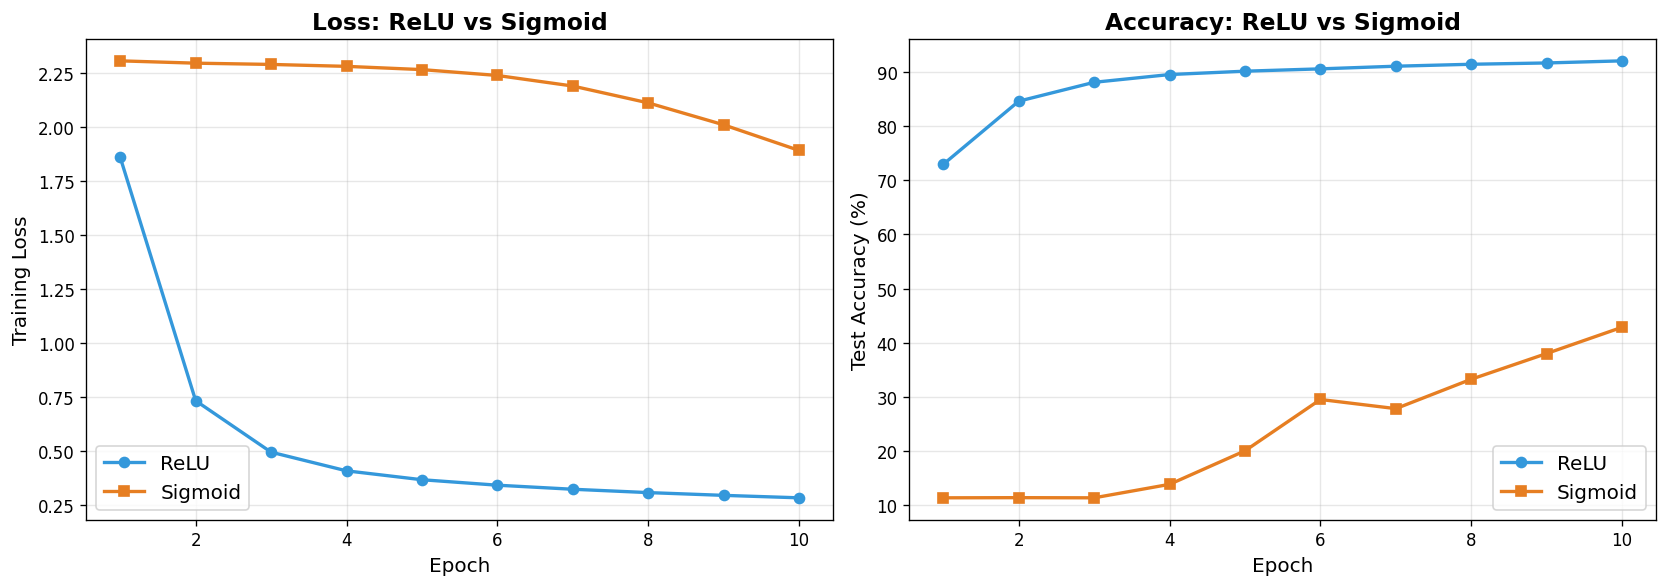

Final accuracy -- ReLU: 92.05%  |  Sigmoid: 42.85%


In [17]:
# Compare ReLU vs Sigmoid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
ax1.plot(range(1, EPOCHS + 1), train_losses, 'o-', label='ReLU', color='#3498db', linewidth=2)
ax1.plot(range(1, EPOCHS + 1), sigmoid_losses, 's-', label='Sigmoid', color='#e67e22', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Loss: ReLU vs Sigmoid', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Accuracy comparison
ax2.plot(range(1, EPOCHS + 1), test_accuracies, 'o-', label='ReLU', color='#3498db', linewidth=2)
ax2.plot(range(1, EPOCHS + 1), sigmoid_accuracies, 's-', label='Sigmoid', color='#e67e22', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('Accuracy: ReLU vs Sigmoid', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final accuracy -- ReLU: {test_accuracies[-1]:.2f}%  |  Sigmoid: {sigmoid_accuracies[-1]:.2f}%')

---
## 13.  Experiment: What if We Use a Bigger Network?

Our tiny 16-neuron hidden layers work, but what about more neurons? Let's try **128** and **64** neurons per hidden layer.

In [18]:
# A bigger MLP
class MLP_Big(nn.Module):
    '''Larger MLP: 784 -> 128 -> 64 -> 10'''
    def __init__(self):
        super(MLP_Big, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.network(x)

model_big = MLP_Big().to(device)
big_params = sum(p.numel() for p in model_big.parameters())
print(f'Bigger model parameters: {big_params:,} (vs. {total_params:,} in the small model)')

optimizer_big = optim.SGD(model_big.parameters(), lr=LEARNING_RATE)

big_losses = []
big_accuracies = []

print('\nTraining bigger model...')
for epoch in range(1, EPOCHS + 1):
    model_big.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_big(images)
        loss = criterion(outputs, labels)
        optimizer_big.zero_grad()
        loss.backward()
        optimizer_big.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    big_losses.append(avg_loss)

    model_big.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_big(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total
    big_accuracies.append(accuracy)
    print(f'  Epoch {epoch:2d}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  Accuracy: {accuracy:.2f}%')

print(f'\nFinal accuracy -- Small (16-16): {test_accuracies[-1]:.2f}%  |  Big (128-64): {big_accuracies[-1]:.2f}%')

Bigger model parameters: 109,386 (vs. 13,002 in the small model)

Training bigger model...
  Epoch  1/10  |  Loss: 1.7271  |  Accuracy: 80.86%
  Epoch  2/10  |  Loss: 0.5737  |  Accuracy: 87.97%
  Epoch  3/10  |  Loss: 0.4033  |  Accuracy: 89.98%
  Epoch  4/10  |  Loss: 0.3485  |  Accuracy: 90.98%
  Epoch  5/10  |  Loss: 0.3183  |  Accuracy: 91.68%
  Epoch  6/10  |  Loss: 0.2961  |  Accuracy: 91.98%
  Epoch  7/10  |  Loss: 0.2782  |  Accuracy: 92.62%
  Epoch  8/10  |  Loss: 0.2628  |  Accuracy: 93.07%
  Epoch  9/10  |  Loss: 0.2492  |  Accuracy: 93.27%
  Epoch 10/10  |  Loss: 0.2364  |  Accuracy: 93.59%

Final accuracy -- Small (16-16): 92.05%  |  Big (128-64): 93.59%


---
## 14.  Try It Yourself — Predict Any Test Image!

Change the `INDEX` variable below to pick any image from the test set (0–9999) and see the network's prediction.

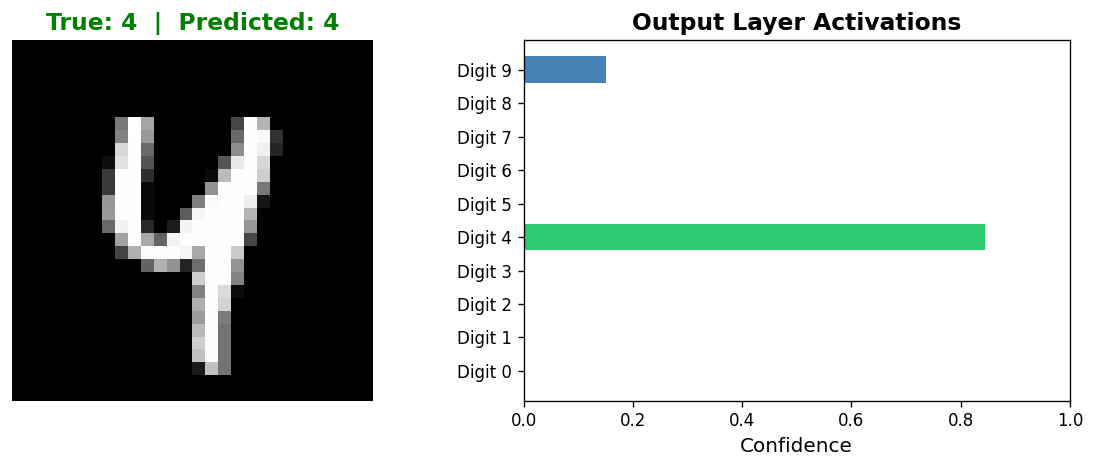

Output layer activations (after softmax):
  Digit 0: 0.0000  
  Digit 1: 0.0000  
  Digit 2: 0.0000  
  Digit 3: 0.0002  
  Digit 4: 0.8451  █████████████████████████████████
  Digit 5: 0.0000  
  Digit 6: 0.0000  
  Digit 7: 0.0013  
  Digit 8: 0.0031  
  Digit 9: 0.1503  ██████


In [19]:
# Change this number to try different images!
INDEX = 42  # <-- Try changing this to any number from 0 to 9999

image, true_label = test_dataset[INDEX]

model.eval()
with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    probs = torch.softmax(output, dim=1).cpu().squeeze().numpy()
    predicted = probs.argmax()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Show the image
ax1.imshow(image.squeeze(), cmap='gray')
color = 'green' if predicted == true_label else 'red'
ax1.set_title(f'True: {true_label}  |  Predicted: {predicted}', fontsize=14, fontweight='bold', color=color)
ax1.axis('off')

# Show confidence
colors = ['steelblue'] * 10
colors[predicted] = '#2ecc71' if predicted == true_label else '#e74c3c'
ax2.barh(range(10), probs, color=colors)
ax2.set_yticks(range(10))
ax2.set_yticklabels([f'Digit {i}' for i in range(10)])
ax2.set_xlabel('Confidence', fontsize=12)
ax2.set_title('Output Layer Activations', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Print the raw output values
print('Output layer activations (after softmax):')
for digit in range(10):
    bar = chr(9608) * int(probs[digit] * 40)
    print(f'  Digit {digit}: {probs[digit]:.4f}  {bar}')

---
##  Summary

| Concept | What We Did |
|---|---|
| **Input Layer** | 784 neurons — one per pixel of the 28×28 image |
| **Hidden Layers** | 2 layers with 16 neurons each (with ReLU activation) |
| **Output Layer** | 10 neurons — one per digit (0–9) |
| **Weights & Biases** | 13,002 parameters that the network *learns* |
| **Forward Pass** | Multiply inputs by weights, add bias, apply activation |
| **Loss Function** | Cross-Entropy — measures how wrong the prediction is |
| **Gradient Descent** | Adjusts weights to reduce the loss |
| **Training** | Repeat forward → loss → backward → update for many epochs |

### Key Takeaways
1. A neural network is just a **function** — 784 inputs in, 10 outputs out.  
2. **Learning** = finding the right 13,002 numbers (weights & biases).  
3. **ReLU** trains faster than **Sigmoid** — we proved it experimentally!  
4. More neurons generally means better accuracy, but also more computation.  
5. Even a simple 2-hidden-layer MLP can achieve **> 90% accuracy** on MNIST!

###  What's Next?
In the next class, we will dive deeper into **Gradient Descent Optimisation** — how the network figures out *which direction* to adjust each of those 13,002 parameters.

---
*End of Module 1 — Hands-On Session*